# 92 antiprotones, 7,5 km por carretera, ninguno perdido

Meter antimateria en un camión y sacarla a la calle. ¿Cuántas partículas llegaron? Las mismas 92 que salieron.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Leonhardt et al. (2026). *Road transport of trapped antiprotons*. **Nature**.
DOI: [10.1038/s41586-026-11019-z](https://doi.org/10.1038/s41586-026-11019-z) · Open Access (CC BY 4.0)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-16-antiprotones-transporte/notebook.ipynb)

**Video:** pendiente

## De qué va esto

Los antiprotones son la antimateria del protón: misma masa, carga opuesta. Cuando uno toca materia normal, se aniquila. Hasta ahora solo se podían estudiar en un sitio del mundo: la *Antimatter Factory* del CERN, en Ginebra. Y ahí hay un problema: los imanes de la propia fábrica hacen ruido magnético que limita la precisión de las medidas.

La solución del equipo BASE-STEP es una trampa portátil (una *trampa de Penning* con imán superconductor, ~850 kg) que se carga con antiprotones, se desconecta de la red y se sube a un camión. El 24 de marzo de 2026 la sacaron a la vía pública con **92 antiprotones a bordo**, dieron dos vueltas a un bucle en las afueras del CERN y volvieron. Después siguieron contando partículas durante un mes.

Tenemos tres archivos de *Source Data* del paper: el track GPS del viaje, el número de antiprotones medido 8.868 veces a lo largo de 33 días, y el rendimiento de extracción de partículas. Veamos qué cuentan.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_INICIAL = 92               # antiprotones cargados en la trampa (paper)
T_TRANSPORTE_D = 16.945      # día (desde la inyección) del transporte por carretera
T_PERDIDA_D = 26.542         # día en que se perdió 1 antiprotón (rampas de voltaje)
T_FIN_D = 32.943             # fin del registro: 32 d 22 h 38 min (Extended Data Table 1)
VENTANA_H = 24               # ventana antes/después del transporte para comparar medias
DIP_1P_HZ = 3.633            # ancho de dip que corresponde a 1 antiproton (paper)
T_GAS_K = 4.3                # temperatura del gas residual en la trampa (paper)
P_DISENO_MBAR = 1e-16        # objetivo de diseño de presión de BASE-STEP
FUENTE = 'Fuente: Leonhardt et al. (2026), Nature | Datos: Source Data Figs. 2-4'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO = '#BBBBBB'

import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
PAPER = f'{BASE}/papers/2026-09-16-antiprotones-transporte'

# Estilo CaM (local -> fallback GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos (descarga automatica si no estan en local)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for f in ['ruta_gps.csv', 'antiprotones_33_dias.csv', 'antiprotones_por_dia.csv', 'extraccion_rendimiento.csv']:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{PAPER}/datos/{f}', f'datos/{f}')

gps = pd.read_csv('datos/ruta_gps.csv')             # 1 punto por segundo
npb = pd.read_csv('datos/antiprotones_33_dias.csv')  # N de antiprotones vs dias
dia = pd.read_csv('datos/antiprotones_por_dia.csv')  # agregado por dia calendario
ext = pd.read_csv('datos/extraccion_rendimiento.csv')

def es(x, dec=0):
    # formato espanol: 8.868 / 7,47
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

print(f'GPS: {es(len(gps))} puntos, {es(gps.dist_km.iloc[-1], 2)} km en {es(gps.t_min.iloc[-1], 1)} min')
print(f'     velocidad máxima {es(gps.vel_kmh.max(), 1)} km/h, media {es(gps.vel_kmh.mean(), 1)} km/h')
print(f'Antiprotones: {es(len(npb))} medidas entre el día {es(npb.t_dias.min(), 2)} y el {es(npb.t_dias.max(), 2)}')
print(f'     N mínimo {es(npb.n_antiprotones.min(), 2)}, máximo {es(npb.n_antiprotones.max(), 2)}, SD {es(npb.n_antiprotones.std(), 2)}')
print(f'Campo magnético (mT) y número de medidas: {npb.B_mT.value_counts().to_dict()}')
print(f'Extracción: {len(ext)} puntos de rendimiento vs posición')

GPS: 1.396 puntos, 7,47 km en 23,4 min
     velocidad máxima 40,7 km/h, media 19,2 km/h
Antiprotones: 8.868 medidas entre el día 0,35 y el 32,92
     N mínimo 88,74, máximo 94,08, SD 0,59
Campo magnético (mT) y número de medidas: {136: 5552, 993: 2744, 880: 572}
Extracción: 14 puntos de rendimiento vs posición


## Aquí está el viaje.

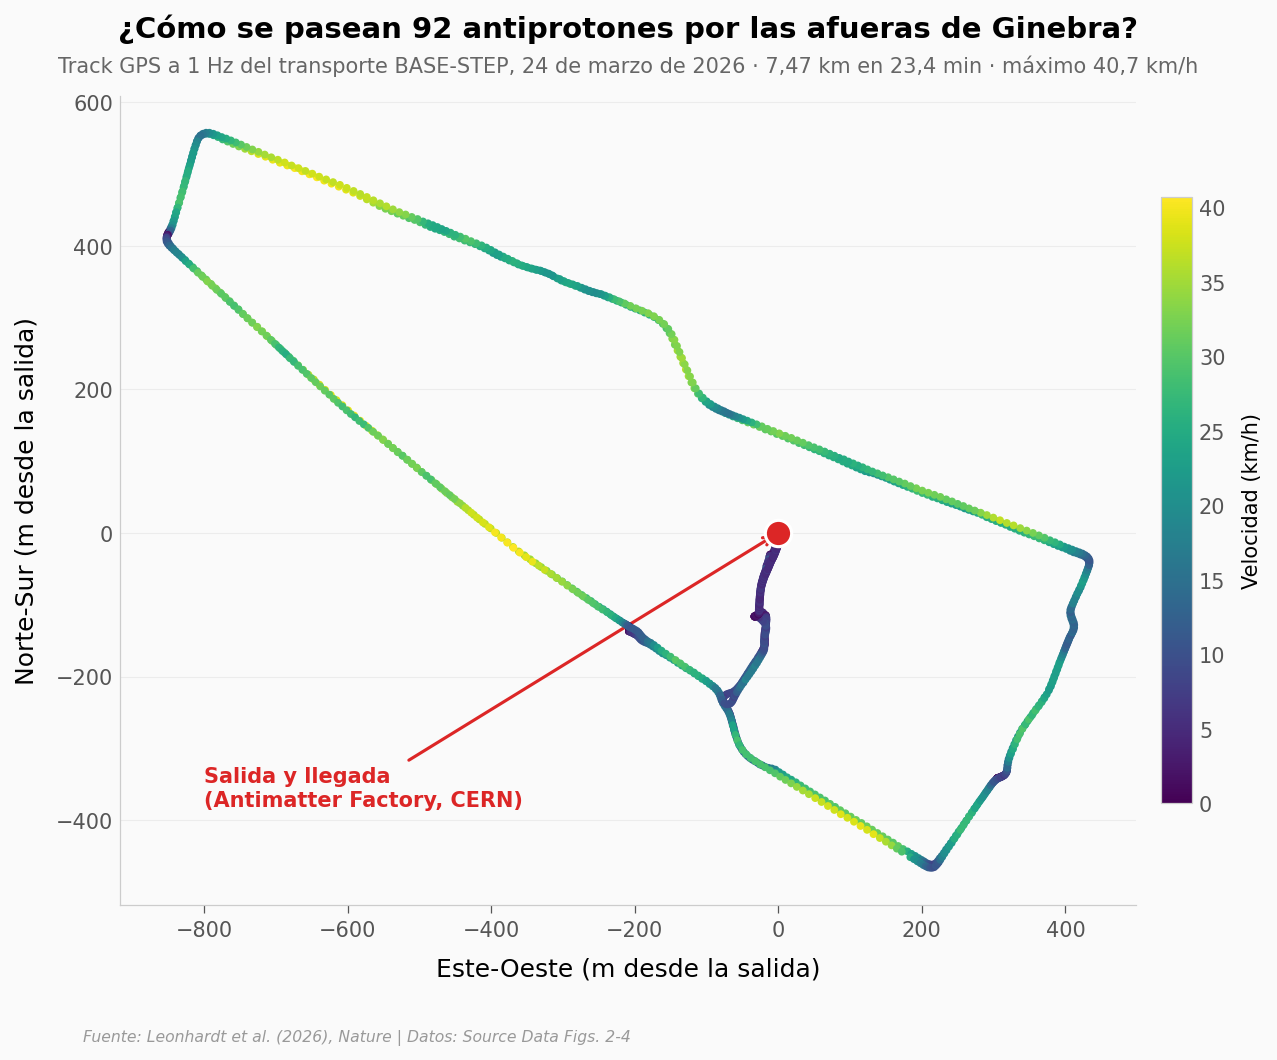

In [2]:
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(gps.x_m, gps.y_m, c=gps.vel_kmh, cmap='viridis', s=14,
                edgecolors='none', zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Velocidad (km/h)', fontsize=10)

# Salida y llegada: el mismo punto (la Antimatter Factory)
ax.scatter([0], [0], s=160, color=COLOR_ALERTA, edgecolors='white', linewidths=1.5, zorder=8)
ax.annotate('Salida y llegada\n(Antimatter Factory, CERN)', xy=(0, 0), xytext=(-800, -380),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_aspect('equal')
ax.set_xlabel('Este-Oeste (m desde la salida)')
ax.set_ylabel('Norte-Sur (m desde la salida)')
ax.set_title('¿Cómo se pasean 92 antiprotones por las afueras de Ginebra?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Track GPS a 1 Hz del transporte BASE-STEP, 24 de marzo de 2026 · '
        f'{es(gps.dist_km.iloc[-1], 2)} km en {es(gps.t_min.iloc[-1], 1)} min · '
        f'máximo {es(gps.vel_kmh.max(), 1)} km/h',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ruta_gps.png', dpi=200, bbox_inches='tight')
plt.show()

Lo primero que llama la atención: la traza se pisa a sí misma. El camión salió de la fábrica, dio **dos vueltas al mismo bucle** por carreteras públicas y volvió al punto de partida. Toda la excursión cabe en un rectángulo de 1,3 km por 1 km.

Lo segundo: no es un paseo de exhibición a paso de tortuga. La velocidad máxima del track es de 40,7 km/h (el paper reporta 40,8), y la media, con semáforos y curvas, 19,2 km/h. Tráfico urbano normal, con frenadas y aceleraciones de hasta 7,3 m/s² según los sensores del paper. Y dentro, un imán superconductor a 6,2 K como máximo — a menos de dos grados de perder la superconductividad (8 K) — sosteniendo 92 antiprotones sin conexión a la red eléctrica.

¿Pero cómo sabemos que llegaron los 92?

## Contar antiprotones durante un mes

La trampa no tiene una ventana para mirar dentro. Lo que el equipo mide es el *ancho de dip*: la nube de antiprotones absorbe energía de un circuito resonante y deja un "hueco" en su espectro de ruido cuya anchura es proporcional al número de partículas. Cada 64 segundos, un espectro; cada espectro, una cuenta. El paper habla de más de 26.000 espectros; el CSV publicado trae 8.868 puntos ya promediados.

Aquí están los 33 días completos, desde la inyección hasta el fin del registro.

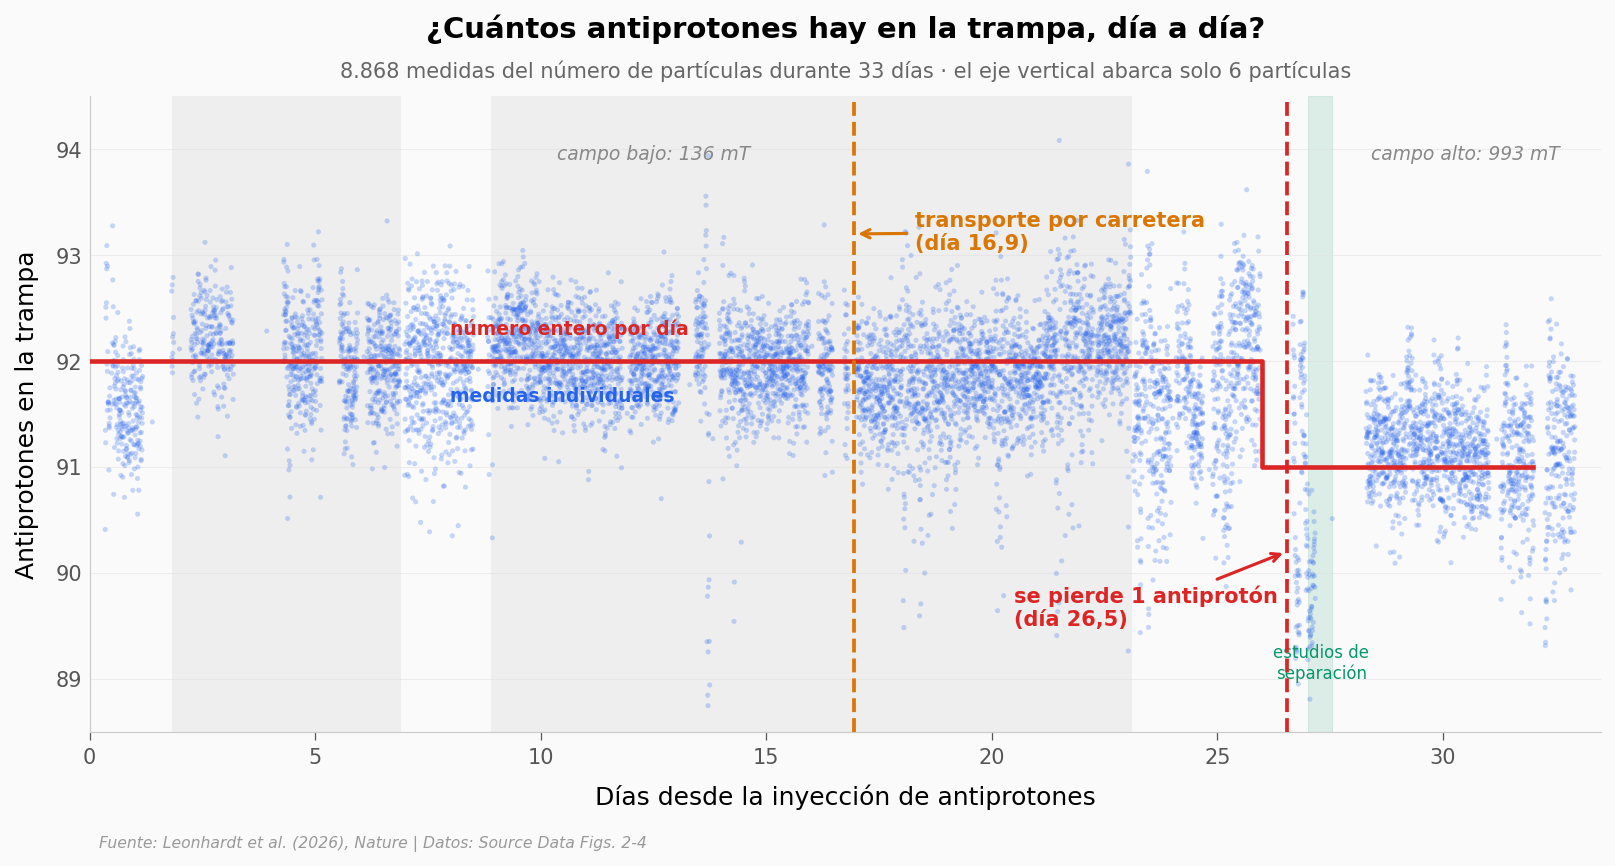

Días calendario que redondean a 92 antiprotones: 26 · a 91: 6 · otros: 1 (día 27)


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Periodos a 136 mT (campo bajo, el de transporte) sombreados en gris claro
seg = (npb.B_mT != npb.B_mT.shift()).cumsum()
for _, g in npb.groupby(seg):
    if g.B_mT.iloc[0] == 136:
        ax.axvspan(g.t_dias.iloc[0], g.t_dias.iloc[-1], color='#EEEEEE', zorder=0)
ax.text(12.5, 93.9, 'campo bajo: 136 mT', fontsize=9, color='#888888', ha='center', style='italic')
ax.text(30.5, 93.9, 'campo alto: 993 mT', fontsize=9, color='#888888', ha='center', style='italic')

ax.scatter(npb.t_dias, npb.n_antiprotones, s=6, color=COLOR_DATOS, alpha=0.25,
           edgecolors='none', zorder=3)
# Numero entero por dia calendario (excluimos el dia 27: estudios de separacion, ver texto)
dia_ok = dia[dia.dia != 27]
ax.step(dia_ok.dia, dia_ok.n_entero, where='post', color=COLOR_ALERTA, linewidth=2.2, zorder=6)
ax.text(8, 92.25, 'número entero por día', fontsize=9, color=COLOR_ALERTA, fontweight='bold')
ax.text(8, 91.62, 'medidas individuales', fontsize=9, color=COLOR_DATOS, fontweight='bold')

# Eventos
ax.axvline(T_TRANSPORTE_D, color=COLOR_REFERENCIA, linewidth=1.8, linestyle='--', zorder=7)
ax.annotate('transporte por carretera\n(día 16,9)', xy=(T_TRANSPORTE_D, 93.2), xytext=(18.3, 93.05),
            fontsize=10, fontweight='bold', color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.5))
ax.axvline(T_PERDIDA_D, color=COLOR_ALERTA, linewidth=1.8, linestyle='--', zorder=7)
ax.annotate('se pierde 1 antiprotón\n(día 26,5)', xy=(T_PERDIDA_D, 90.2), xytext=(20.5, 89.5),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax.axvspan(27.0, 27.55, color=COLOR_SECUNDARIO, alpha=0.12, zorder=1)
ax.text(27.3, 89.0, 'estudios de\nseparación', fontsize=8, color=COLOR_SECUNDARIO, ha='center')

ax.set_ylim(88.5, 94.5)
ax.set_xlim(0, 33.5)
ax.set_xlabel('Días desde la inyección de antiprotones')
ax.set_ylabel('Antiprotones en la trampa')
ax.set_title('¿Cuántos antiprotones hay en la trampa, día a día?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{es(len(npb))} medidas del número de partículas durante 33 días · el eje vertical abarca solo 6 partículas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/antiprotones_33_dias.png', dpi=200, bbox_inches='tight')
plt.show()

n92 = int((dia.n_entero == 92).sum()); n91 = int((dia.n_entero == 91).sum())
print(f'Días calendario que redondean a 92 antiprotones: {n92} · a 91: {n91} · otros: {len(dia) - n92 - n91} (día 27)')

El eje vertical engaña a primera vista: la nube azul parece ruidosa, pero abarca apenas seis partículas. La desviación estándar de las 8.868 medidas es de 0,59 antiprotones, y la mitad central de los datos cae entre 91,45 y 92,16. La medida no distingue partículas enteras en un solo espectro, pero sí en el promedio: 26 de los 33 días redondean exactamente a 92, 6 a 91, y el que falta es el día 27 (ahora vamos con él).

Y ahí está la única pérdida del mes: el día 26,5, durante unas rampas de voltaje en el laboratorio, ya de vuelta. No en el camión. El día 27 sale más bajo (89,8) porque el equipo estaba haciendo estudios de separación: parte del reservorio estaba temporalmente fuera del pozo central. No es una pérdida, y por eso lo excluimos de la línea roja.

Acerquémonos al transporte.

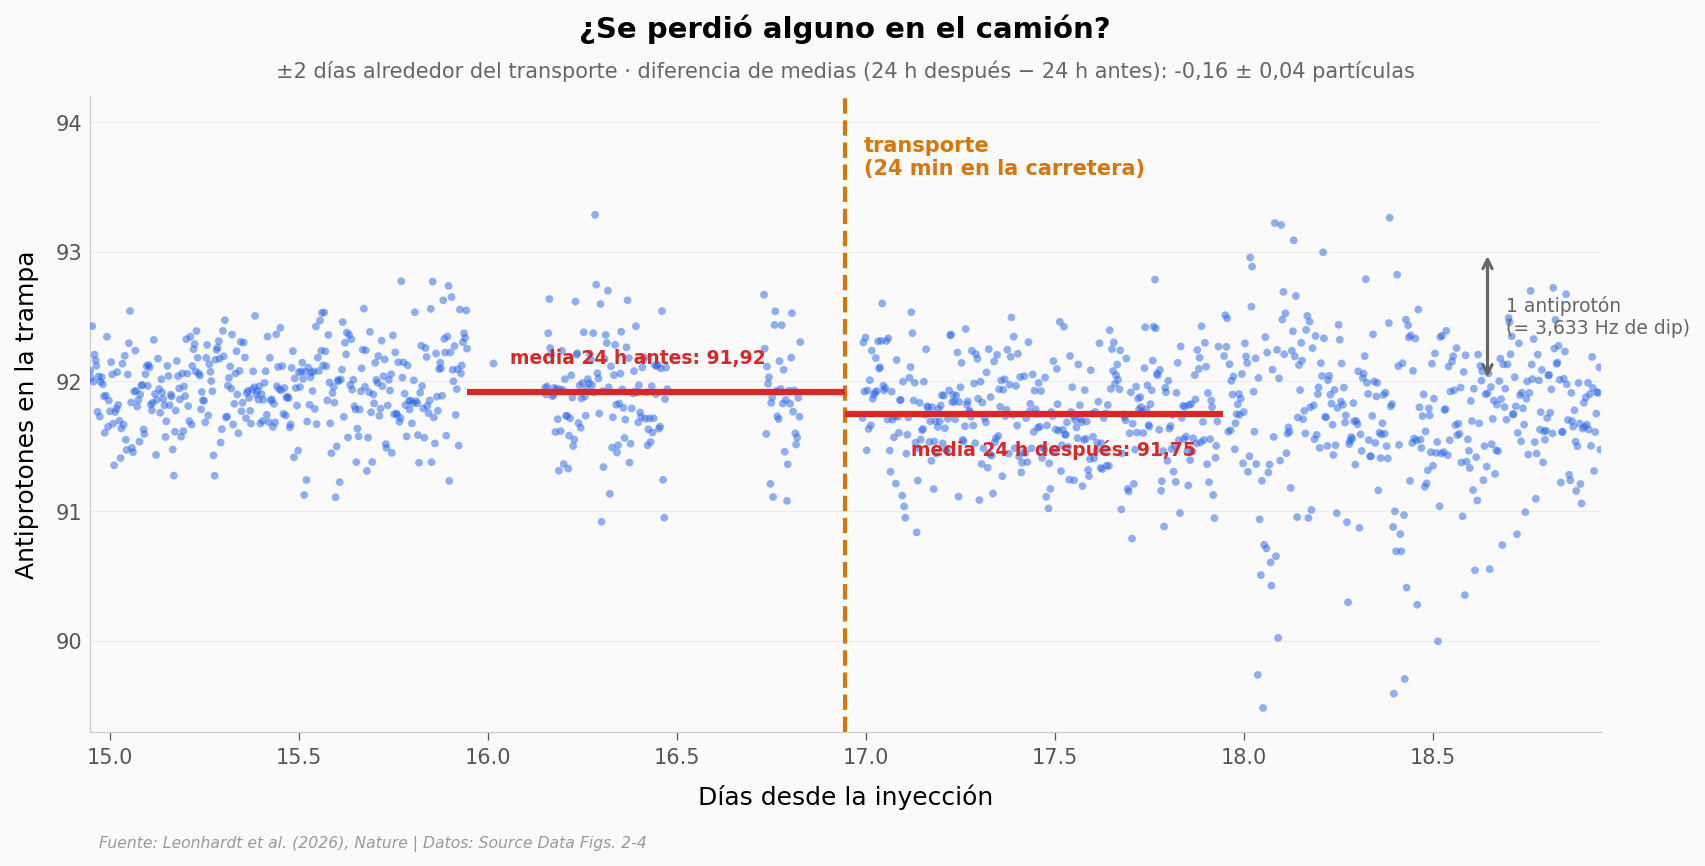

Ventana antes:   n = 155 medidas, media = 91,915
Ventana después: n = 342 medidas, media = 91,751
Diferencia = -0,164 ± 0,035 antiprotones  (paper, del ancho de dip: 333,92 − 334,08 Hz = −0,16 Hz = −0,044 partículas)
Hueco más largo sin medidas en la ventana previa: 369 min (modo autónomo y grúa)


In [4]:
h = VENTANA_H / 24
pre = npb[(npb.t_dias >= T_TRANSPORTE_D - h) & (npb.t_dias < T_TRANSPORTE_D)]
post = npb[(npb.t_dias > T_TRANSPORTE_D) & (npb.t_dias <= T_TRANSPORTE_D + h)]
m_pre, m_post = pre.n_antiprotones.mean(), post.n_antiprotones.mean()
delta = m_post - m_pre
se = np.sqrt(pre.n_antiprotones.var(ddof=1) / len(pre) + post.n_antiprotones.var(ddof=1) / len(post))

zoom = npb[(npb.t_dias > T_TRANSPORTE_D - 2) & (npb.t_dias < T_TRANSPORTE_D + 2)]
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.scatter(zoom.t_dias, zoom.n_antiprotones, s=14, color=COLOR_DATOS, alpha=0.5,
           edgecolors='none', zorder=3)
ax.axvline(T_TRANSPORTE_D, color=COLOR_REFERENCIA, linewidth=2, linestyle='--', zorder=7)
ax.text(T_TRANSPORTE_D + 0.05, 93.9, 'transporte\n(24 min en la carretera)', fontsize=10,
        fontweight='bold', color=COLOR_REFERENCIA, va='top')

ax.hlines(m_pre, T_TRANSPORTE_D - h, T_TRANSPORTE_D, color=COLOR_ALERTA, linewidth=3, zorder=8)
ax.hlines(m_post, T_TRANSPORTE_D, T_TRANSPORTE_D + h, color=COLOR_ALERTA, linewidth=3, zorder=8)
ax.text(T_TRANSPORTE_D - 0.55, m_pre + 0.22, f'media 24 h antes: {m_pre:.2f}'.replace('.', ','),
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center')
ax.text(T_TRANSPORTE_D + 0.55, m_post - 0.32, f'media 24 h después: {m_post:.2f}'.replace('.', ','),
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center')

# Escala: cuanto es 1 antiproton en este eje
ax.annotate('', xy=(T_TRANSPORTE_D + 1.7, 92.0), xytext=(T_TRANSPORTE_D + 1.7, 93.0),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(T_TRANSPORTE_D + 1.75, 92.5, '1 antiprotón\n(= 3,633 Hz de dip)', fontsize=9, color='#666666', va='center')

ax.set_ylim(89.3, 94.2)
ax.set_xlim(T_TRANSPORTE_D - 2, T_TRANSPORTE_D + 2)
ax.set_xlabel('Días desde la inyección')
ax.set_ylabel('Antiprotones en la trampa')
ax.set_title('¿Se perdió alguno en el camión?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'±2 días alrededor del transporte · diferencia de medias (24 h después − 24 h antes): '
        f'{delta:+.2f} ± {se:.2f} partículas'.replace('.', ','),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/zoom_transporte.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Ventana antes:   n = {len(pre)} medidas, media = {es(m_pre, 3)}')
print(f'Ventana después: n = {len(post)} medidas, media = {es(m_post, 3)}')
print(f'Diferencia = {es(delta, 3)} ± {es(se, 3)} antiprotones  (paper, del ancho de dip: 333,92 − 334,08 Hz = −0,16 Hz = −0,044 partículas)')
print(f'Hueco más largo sin medidas en la ventana previa: {np.diff(pre.t_dias.values).max() * 1440:.0f} min (modo autónomo y grúa)')

La diferencia entre las 24 h anteriores y las 24 h posteriores al viaje es de −0,16 ± 0,04 partículas. Ojo con leerlo como "se perdió una fracción": un antiprotón es indivisible, no se pierde 0,16 de uno. Un corrimiento tan pequeño es deriva de calibración del ancho de dip (el paper, con su propio análisis en hercios, obtiene −0,044 partículas). Lo que cuenta es la escala: la flecha gris muestra cuánto mediría **un** antiprotón perdido, y ninguna de las dos medias se acerca a ese escalón. El transporte por carretera no costó ninguna partícula.

Pero, ¿de verdad la medida es capaz de ver un antiprotón menos? Sí — y tenemos la prueba nueve días después.

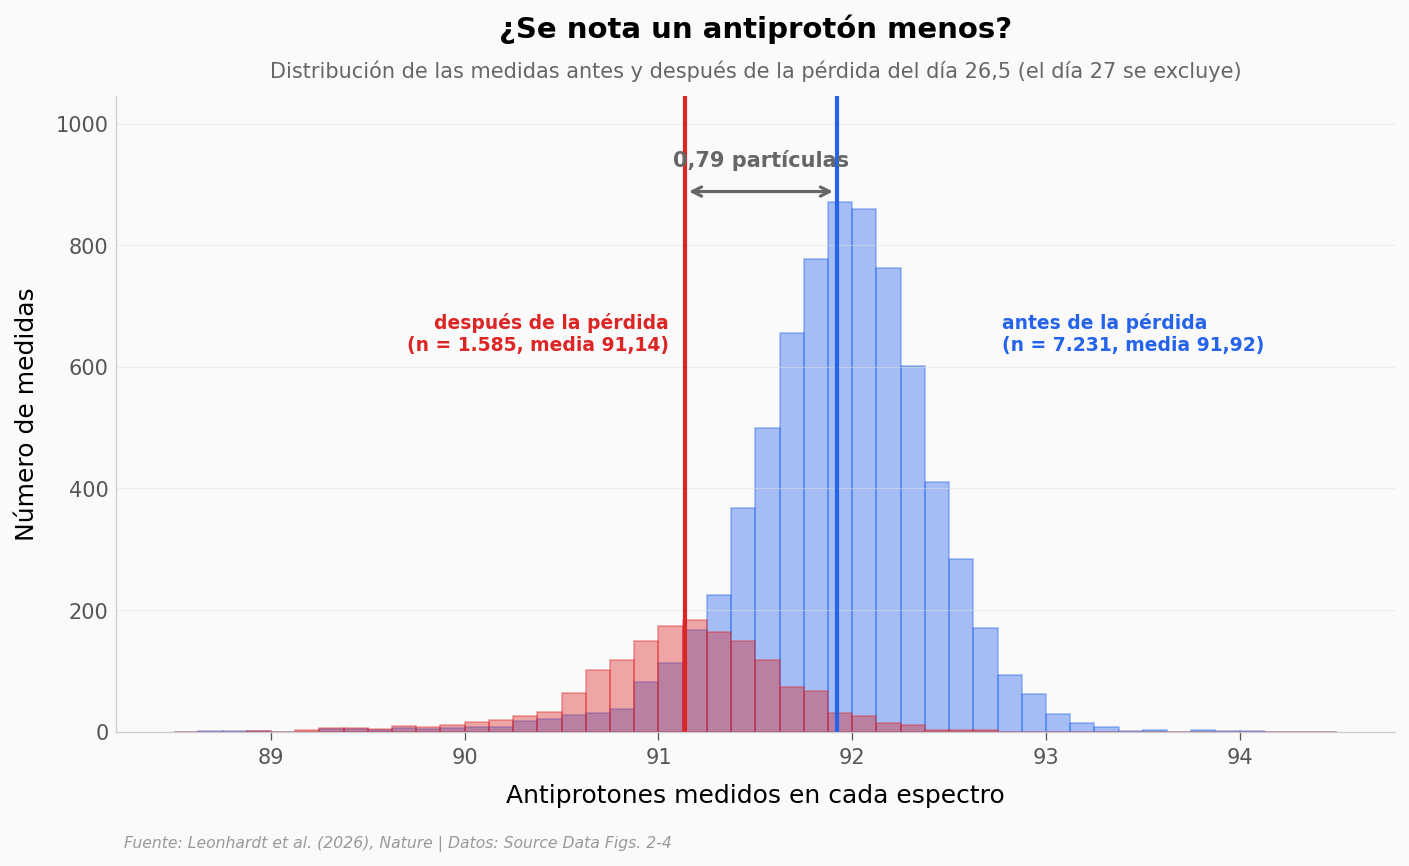

Media antes de la pérdida:   91,922  (n = 7.231)
Media después de la pérdida: 91,136  (n = 1.585)
Escalón medido: 0,79 partículas — el paper lo reporta como 92 → 91


In [5]:
antes = npb[npb.t_dias < T_PERDIDA_D].n_antiprotones
# Despues de la perdida, excluyendo el dia 27 (estudios de separacion, no es perdida)
despues = npb[(npb.t_dias > T_PERDIDA_D) & ~((npb.t_dias >= 27.0) & (npb.t_dias < 28.0))].n_antiprotones
m_a, m_d = antes.mean(), despues.mean()

fig, ax = plt.subplots(figsize=(11, 5.5))
bins = np.linspace(88.5, 94.5, 49)
n_a, _, _ = ax.hist(antes, bins=bins, color=COLOR_DATOS, alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
n_d, _, _ = ax.hist(despues, bins=bins, color=COLOR_ALERTA, alpha=0.4, edgecolor=COLOR_ALERTA, linewidth=0.8)
y_max = max(n_a.max(), n_d.max()) * 1.2
ax.set_ylim(0, y_max)

ax.axvline(m_a, color=COLOR_DATOS, linewidth=2)
ax.axvline(m_d, color=COLOR_ALERTA, linewidth=2)
ax.annotate('', xy=(m_d, y_max * 0.85), xytext=(m_a, y_max * 0.85),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((m_a + m_d) / 2, y_max * 0.89, f'{m_a - m_d:.2f} partículas'.replace('.', ','),
        fontsize=10, fontweight='bold', color='#666666', ha='center')
ax.text(m_a + 0.85, y_max * 0.6, f'antes de la pérdida\n(n = {es(len(antes))}, media {es(m_a, 2)})',
        fontsize=9, color=COLOR_DATOS, fontweight='bold')
ax.text(m_d - 0.08, y_max * 0.6, f'después de la pérdida\n(n = {es(len(despues))}, media {es(m_d, 2)})',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='right')

ax.set_xlabel('Antiprotones medidos en cada espectro')
ax.set_ylabel('Número de medidas')
ax.set_title('¿Se nota un antiprotón menos?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de las medidas antes y después de la pérdida del día 26,5 (el día 27 se excluye)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_perdida.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Media antes de la pérdida:   {es(m_a, 3)}  (n = {es(len(antes))})')
print(f'Media después de la pérdida: {es(m_d, 3)}  (n = {es(len(despues))})')
print(f'Escalón medido: {es(m_a - m_d, 2)} partículas — el paper lo reporta como 92 → 91')

Se nota. Las dos distribuciones se separan un escalón de casi una partícula (0,79 en el promedio; la calibración del dip no es perfecta al segundo decimal, pero el salto es inequívoco). Con esta resolución, la conclusión sobre el camión se sostiene: si se hubiera perdido un antiprotón por el camino, lo veríamos igual que vemos este.

Y aquí viene lo bonito. Que en 33 días se pierda como mucho un antiprotón —y ese por una maniobra de voltaje, no por chocar con gas— nos dice algo sobre el vacío dentro de la trampa. Cada antiprotón que sobrevive es un detector: si hubiera moléculas de gas residual, se aniquilaría con ellas. Podemos convertir "cero aniquilaciones en 8,3 años-partícula" (92 antiprotones durante 33 días equivalen a uno solo vigilado durante 8,3 años) en un límite de presión.

Tiempo integrado de almacenamiento: 8,280 años-partícula (paper: 8,280)
  vida media mínima al 68% de confianza: 7,27 años
  vida media mínima al 90% de confianza: 3,60 años
  vida media mínima al 95% de confianza: 2,76 años
σv hidrógeno = 2.69e-15 m³/s · k_L helio = 1.18e-15 m³/s
p(H)  < 9.6e-19 mbar   (paper: 9,6e-19)
p(He) < 2.2e-18 mbar   (paper: 2,2e-18)
A esa presión y 4,3 K hay 3,7 moléculas por cm³ · la atmósfera tiene 2.5×10^19 por cm³: 6.8×10^18 veces más
En presión, la atmósfera (1.013 mbar) es 4.6×10^20 veces mayor
Objetivo de diseño: 1e-16 mbar → lo medido es 46 veces mejor


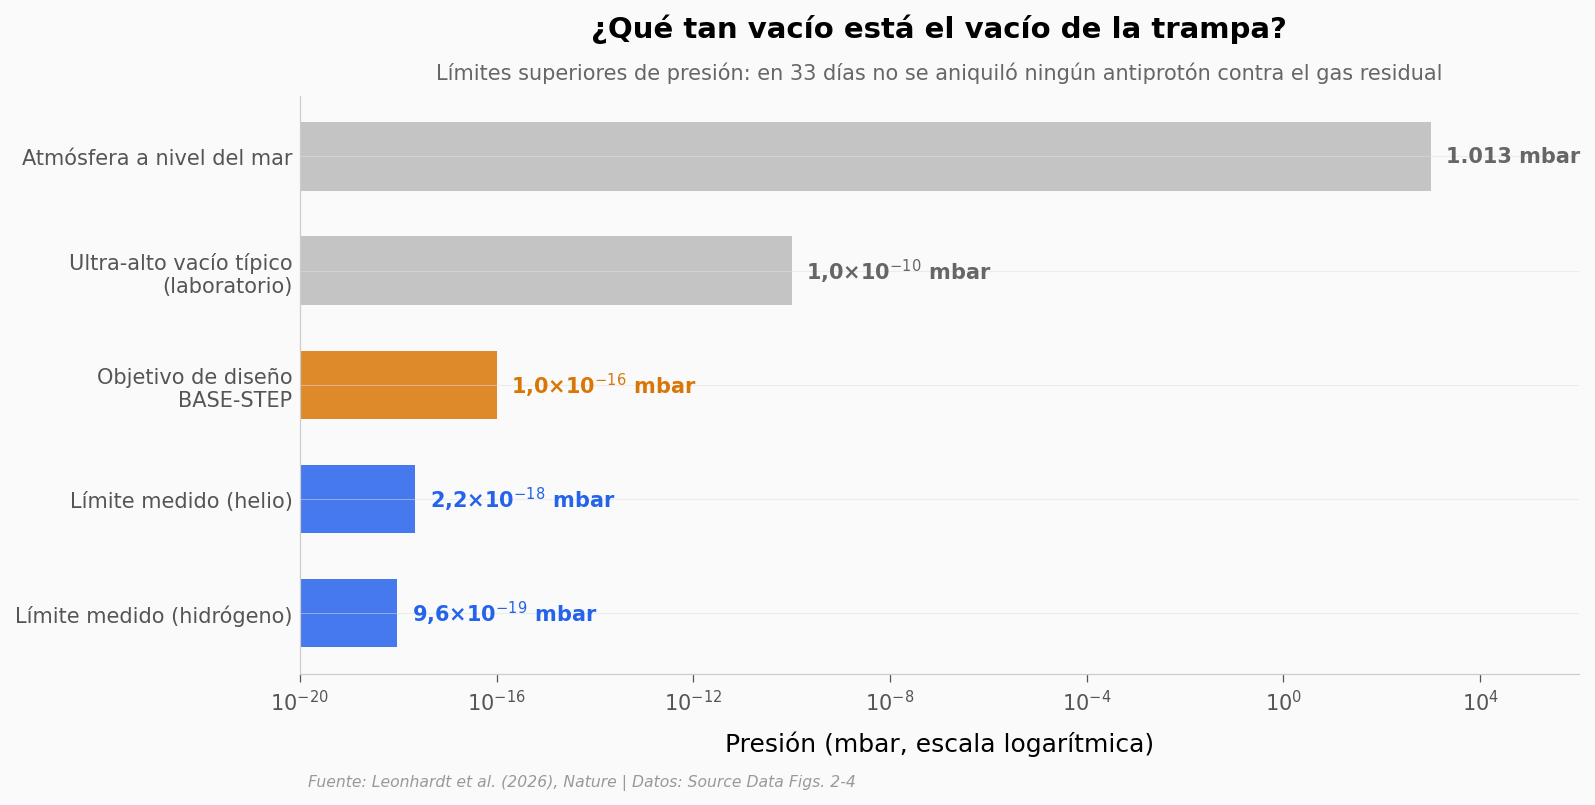

In [6]:
# Tiempo integrado de almacenamiento: 92 antiprotones hasta la perdida, 91 despues
T_int_a = (T_PERDIDA_D * N_INICIAL + (T_FIN_D - T_PERDIDA_D) * (N_INICIAL - 1)) / 365.25

# Poisson con 0 aniquilaciones observadas: tau > T_int / -ln(1 - CL)
tau = {cl: T_int_a / -np.log(1 - cl) for cl in (0.68, 0.90, 0.95)}

# Presion parcial: p = k_B * T_gas / (tau * sigma_v)   [Pa]
k_B = 1.380649e-23; e = 1.602176634e-19; eps0 = 8.8541878128e-12
a0 = 5.29177e-11; u = 1.66053907e-27
m_p = 1.007276 * u; m_He = 4.002602 * u
# Hidrogeno: seccion eficaz de aniquilacion de Bracci et al. (1979), sigma*v = 6*pi*a0^2 * sqrt(E0/m)
E0 = 27.2 * e
sv_H = 6 * np.pi * a0**2 * np.sqrt(E0 / m_p)
# Helio: constante de Langevin k_L = 2*pi*sqrt(alpha/mu) * e/sqrt(4*pi*eps0), alpha(He) = 0,205 A^3
alpha_He = 0.205e-30; mu = m_p * m_He / (m_p + m_He)
sv_He = 2 * np.pi * np.sqrt(alpha_He / mu) * e / np.sqrt(4 * np.pi * eps0)
tau_s = tau[0.68] * 365.25 * 86400
p_H_mbar = k_B * T_GAS_K / (tau_s * sv_H) / 100
p_He_mbar = k_B * T_GAS_K / (tau_s * sv_He) / 100
n_cm3 = (p_He_mbar * 100) / (k_B * T_GAS_K) / 1e6
ratio_atm = 1013.25 / p_He_mbar
n_atm_cm3 = 101325 / (k_B * 293.15) / 1e6          # moleculas por cm3 en aire a 20 C
ratio_dens = n_atm_cm3 / n_cm3

print(f'Tiempo integrado de almacenamiento: {es(T_int_a, 3)} años-partícula (paper: 8,280)')
for cl, t in tau.items():
    print(f'  vida media mínima al {cl:.0%} de confianza: {es(t, 2)} años')
print(f'σv hidrógeno = {sv_H:.2e} m³/s · k_L helio = {sv_He:.2e} m³/s')
print(f'p(H)  < {p_H_mbar:.1e} mbar   (paper: 9,6e-19)')
print(f'p(He) < {p_He_mbar:.1e} mbar   (paper: 2,2e-18)')
print(f'A esa presión y {es(T_GAS_K, 1)} K hay {es(n_cm3, 1)} moléculas por cm³ · la atmósfera tiene {n_atm_cm3:.1e} por cm³: {ratio_dens:.1e} veces más'.replace('e+', '×10^'))
print(f'En presión, la atmósfera (1.013 mbar) es {ratio_atm:.1e} veces mayor'.replace('e+', '×10^'))
print(f'Objetivo de diseño: {P_DISENO_MBAR:.0e} mbar → lo medido es {P_DISENO_MBAR / p_He_mbar:.0f} veces mejor')

# Grafica: donde cae este vacio
niveles = [
    ('Atmósfera a nivel del mar', 1013.25, COLOR_CONTEXTO),
    ('Ultra-alto vacío típico\n(laboratorio)', 1e-10, COLOR_CONTEXTO),
    ('Objetivo de diseño\nBASE-STEP', P_DISENO_MBAR, COLOR_REFERENCIA),
    ('Límite medido (helio)', p_He_mbar, COLOR_DATOS),
    ('Límite medido (hidrógeno)', p_H_mbar, COLOR_DATOS),
]
fig, ax = plt.subplots(figsize=(11, 5))
ys = np.arange(len(niveles))[::-1]
def sci(p):
    # 2.2e-18 -> '2,2×10$^{-18}$' (math text para el superindice)
    ex = int(np.floor(np.log10(p))); m = p / 10**ex
    return f'{m:.1f}×10$^{{{ex}}}$'.replace('.', ',')
for y, (lab, p, c) in zip(ys, niveles):
    ax.barh(y, np.log10(p) + 20, color=c, alpha=0.85, height=0.6)
    ax.text(np.log10(p) + 20 + 0.3, y, (sci(p) if p < 1 else '1.013') + ' mbar',
            va='center', fontsize=10, fontweight='bold', color=c if c != COLOR_CONTEXTO else '#666666')
ax.set_yticks(ys)
ax.set_yticklabels([n[0] for n in niveles], fontsize=10)
ticks = np.arange(0, 25, 4)
ax.set_xticks(ticks)
ax.set_xticklabels([f'10$^{{{t - 20}}}$' for t in ticks])
ax.set_xlim(0, 26)
ax.set_xlabel('Presión (mbar, escala logarítmica)')
ax.set_title('¿Qué tan vacío está el vacío de la trampa?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Límites superiores de presión: en 33 días no se aniquiló ningún antiprotón contra el gas residual',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/vacio_presion.png', dpi=200, bbox_inches='tight')
plt.show()

Menos de 4 moléculas por centímetro cúbico. La atmósfera que respiras tiene unas 2,5×10¹⁹ por cm³; este vacío tiene una presión 4,6×10²⁰ veces menor (en moléculas por cm³, unas 7×10¹⁸ veces menos: a 4,3 K cada molécula "pesa" menos presión que a temperatura ambiente), y es 46 veces mejor que el objetivo de diseño de la trampa. Todo eso sale de una cuenta muy simple: contar antiprotones y ver que no desaparecen.

Un matiz que el paper deja claro y nosotros también: el límite al 68% de confianza (7,27 años de vida media) es el que usan los autores. Al 95% baja a 2,76 años, y si asumiéramos que la pérdida del día 26,5 fue una aniquilación (no lo fue: coincidió con rampas de voltaje), el propio paper da un escenario conservador de τ > 3,6 años y p < 4,4×10⁻¹⁸ mbar. Los órdenes de magnitud no cambian.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El transporte recorrió 7,5 km por carretera en unos 24 min | ✅ | Track GPS: 7,47 km de distancia acumulada (1.396 puntos a 1 Hz; calculada sobre las coordenadas originales a plena precisión — las lat/lon del CSV van redondeadas a 4 decimales) en 23,4 min; velocidad máxima 40,7 km/h (paper: 40,8) |
| No se perdió ningún antiprotón durante el transporte | ✅ | Diferencia de medias 24 h después − 24 h antes: −0,16 ± 0,04 partículas, muy por debajo del escalón de 1 partícula (3,633 Hz). El paper obtiene −0,044 partículas con su análisis en hercios |
| La trampa mantuvo 92 antiprotones durante 26,5 días y 91 después | ✅ | 26 días calendario redondean a 92 y 6 a 91; el escalón medido en la pérdida es de 0,79 partículas (día 27 excluido: estudios de separación) |
| La pérdida del día 26,5 no fue una aniquilación con gas residual | ⚠️ | El paper la atribuye a rampas de voltaje por coincidencia temporal (Extended Data Table 1); nosotros solo vemos el escalón, no la causa |
| Vida media mínima de 7,27 años y presión por debajo de 2,2×10⁻¹⁸ mbar (He) y 9,6×10⁻¹⁹ mbar (H) | ✅ | Replicamos la cuenta del paper: Poisson con 0 aniquilaciones en 8,280 años-partícula al 68% de confianza; σ de Bracci (1979) para H y constante de Langevin para He |
| Esta trampa permitirá tests de simetría materia-antimateria 100 veces mejores | ⚠️ | Es una proyección de los autores ("expected to enable"), no una medida. Nada en estos datos la comprueba |

> **Limitaciones:** el CSV de la Fig. 3 trae 8.868 puntos ya promediados, no los >26.000 espectros brutos de 64 s, y ya incluye los factores de corrección de los primeros días. El número de antiprotones es un valor continuo calibrado a partir del ancho de dip: desplazamientos de décimas de partícula son deriva de calibración, no partículas. Nuestras ventanas de ±24 h alrededor del transporte tienen un hueco de más de 6 h sin medidas antes del viaje (modo autónomo y traslado en grúa), y el error que reportamos es el error estándar de la diferencia de medias entre ventanas, sin corregir la autocorrelación temporal. El día 27 (52 medidas a 89,8) lo dejamos fuera de los promedios porque el paper documenta que ese día hubo estudios de separación, no una pérdida. Los límites de presión dependen de una temperatura de gas asumida de 4,3 K y de secciones eficaces teóricas; son cotas superiores, no medidas directas de presión.

## Ahora tú

1. **¿Qué pasa con el límite de presión si el gas estuviera más caliente?** El paper asume 4,3 K. Cambia `T_GAS_K` a 10 o a 300 K en la celda de configuración y vuelve a ejecutar la celda del vacío. ¿Por qué la presión sube pero el número de moléculas por cm³ no cambia?

2. **¿Cuánto cambia la conclusión sobre el transporte con otra ventana?** Prueba `VENTANA_H = 6` y `VENTANA_H = 48`. ¿La diferencia de medias se acerca alguna vez al escalón de 1 partícula? Pista: mira también cuántas medidas caen en cada ventana (`len(pre)`, `len(post)`).

3. **¿A qué distancia del electrodo se separa exactamente un antiprotón?** El archivo `ext` tiene el rendimiento de extracción frente a la posición del centro de masa de la nube. Ajusta una función sigmoide (`scipy.special.erf`) y estima la anchura de la transición. Pista: `scipy.optimize.curve_fit` con `lambda x, x0, w: 0.5 * (1 + erf((x - x0) / w))`.

In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿cómo cambia la diferencia antes/después con el tamaño de la ventana?
print('Ventana (h)   n antes   n después   diferencia ± error (partículas)')
for horas in (3, 6, 12, 24, 48, 96):
    hh = horas / 24
    a = npb[(npb.t_dias >= T_TRANSPORTE_D - hh) & (npb.t_dias < T_TRANSPORTE_D)].n_antiprotones
    b = npb[(npb.t_dias > T_TRANSPORTE_D) & (npb.t_dias <= T_TRANSPORTE_D + hh)].n_antiprotones
    d = b.mean() - a.mean()
    err = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    print(f'{horas:>8}    {len(a):>6}    {len(b):>8}     {d:+.3f} ± {err:.3f}'.replace('.', ','))
print('\nNinguna ventana se acerca al escalón de 1 partícula.')

Ventana (h)   n antes   n después   diferencia ± error (partículas)
       3         3          30     -0,001 ± 0,182
       6        36          75     -0,099 ± 0,078
      12        47         165     -0,086 ± 0,064
      24       155         342     -0,164 ± 0,035
      48       517         702     -0,193 ± 0,023
      96      1030        1424     -0,167 ± 0,018

Ninguna ventana se acerca al escalón de 1 partícula.


## Créditos

- **Paper:** Leonhardt, D. et al. (2026). *Road transport of trapped antiprotons*. Nature. DOI: [10.1038/s41586-026-11019-z](https://doi.org/10.1038/s41586-026-11019-z). Licencia CC BY 4.0.
- **Datos:** Source Data de las Figs. 2, 3 y 4 del paper (MOESM2–4), convertidos a CSV. Coordenadas locales, distancia y velocidad del track GPS derivadas por nosotros conservando el orden de registro original.
- **Código:** [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-16-antiprotones-transporte) — MIT.

## Fuentes

**Paper**: [Road transport of trapped antiprotons](https://doi.org/10.1038/s41586-026-11019-z)  
*Nature, 2026-09-16*

**Supplementary Material**: [Source Data Fig. 2 — Road transport of trapped antiprotons (MOESM2)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11019-z/MediaObjects/41586_2026_11019_MOESM2_ESM.csv)  
*Nature, 2026-09-16*

**Supplementary Material**: [Source Data Fig. 3 — Road transport of trapped antiprotons (MOESM3)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11019-z/MediaObjects/41586_2026_11019_MOESM3_ESM.csv)  
*Nature, 2026-09-16*

**Supplementary Material**: [Source Data Fig. 4 — Road transport of trapped antiprotons (MOESM4)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11019-z/MediaObjects/41586_2026_11019_MOESM4_ESM.csv)  
*Nature, 2026-09-16*

**Supplementary Material**: [Extended Data Table 1 — Antiproton reservoir event timeline](https://www.nature.com/articles/s41586-026-11019-z/tables/1)  
*Nature, 2026-09-16*

**Referencias citadas**: [Proton transport from the antimatter factory of CERN](https://doi.org/10.1038/s41586-025-08926-y), [BASE-STEP: a transportable antiproton reservoir for fundamental interaction studies](https://doi.org/10.1063/5.0155492), [Protonium formation in flight](https://doi.org/10.1016/0370-2693(79)90597-5)

*24 afirmaciones del notebook verificadas contra estas fuentes*